# Day 3 — EDA Charts: Visualising SQL Findings

## Objective
Translate the 8 SQL findings from Day 2 into 5 professional charts.
Each chart is designed around one specific insight, not just data display.
All charts saved to `charts/` as PNG files for use in the README and Power BI.

## Charts
1. Monthly SLA breach rate trend (with spike annotations)
2. Breach severity breakdown (donut + bar)
3. Seller vs carrier delivery time split
4. Top 10 seller states by breach rate
5. Breach rate by order value tier

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Chart style — consistent with Project 1
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load clean dataset
df = pd.read_csv('../data/clean/orders_clean.csv', parse_dates=['order_purchase_timestamp'])

print(f"Loaded: {df.shape[0]:,} rows | {df.shape[1]} columns")
print(f"Date range: {df['order_purchase_timestamp'].min().date()} "
      f"to {df['order_purchase_timestamp'].max().date()}")
print(f"Overall breach rate: {df['sla_breached'].mean()*100:.2f}%")

Loaded: 96,470 rows | 28 columns
Date range: 2016-09-15 to 2018-08-29
Overall breach rate: 6.77%


## Chart 1 — Monthly SLA Breach Rate Trend

**Insight being visualised:** SLA performance has improved overall but
suffered two significant spikes November 2017 (12.40%) and March 2018
(18.96%), both coinciding with peak order volume periods.

**Design decisions:**
- Area fill under the line emphasises the magnitude of spikes visually
- Annotations mark the two anomalous months so the reader doesn't have
  to hunt for them
- Platform average shown as a dashed reference line
- Months with fewer than 100 orders excluded (2016-09, 2016-12),
  single-digit order counts produce statistically meaningless rates

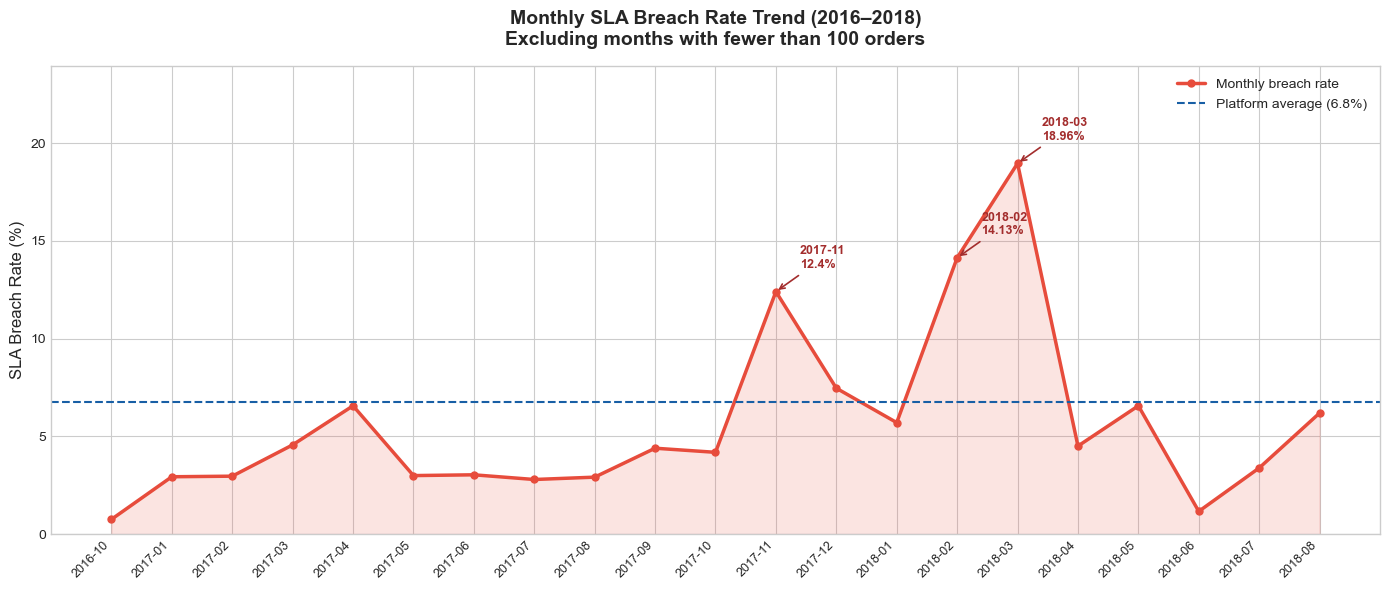

Chart 1 saved ✅
Peak month: 2018-03 — 18.96%
Best month: 2016-10 — 0.75%


In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

# Build monthly summary
df['year_month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly = (df.groupby('year_month')
             .agg(total_orders=('sla_breached','count'),
                  breached=('sla_breached','sum'))
             .reset_index())
monthly['breach_rate'] = (monthly['breached'] / monthly['total_orders'] * 100).round(2)
monthly['year_month_str'] = monthly['year_month'].astype(str)

# Exclude months with fewer than 100 orders (statistically unreliable)
monthly = monthly[monthly['total_orders'] >= 100].reset_index(drop=True)

# Plot line + area fill
ax.fill_between(range(len(monthly)), monthly['breach_rate'],
                alpha=0.15, color='#E74C3C')
ax.plot(range(len(monthly)), monthly['breach_rate'],
        color='#E74C3C', linewidth=2.5, marker='o',
        markersize=5, label='Monthly breach rate')

# Platform average reference line
platform_avg = df['sla_breached'].mean() * 100
ax.axhline(y=platform_avg, color='#185FA5', linestyle='--',
           linewidth=1.5, label=f'Platform average ({platform_avg:.1f}%)')

# Annotate the two spike months
spikes = monthly[monthly['breach_rate'] > 10]
for _, row in spikes.iterrows():
    idx = monthly[monthly['year_month_str'] == row['year_month_str']].index[0]
    ax.annotate(f"{row['year_month_str']}\n{row['breach_rate']}%",
                xy=(idx, row['breach_rate']),
                xytext=(idx + 0.4, row['breach_rate'] + 1.2),
                fontsize=9, fontweight='bold', color='#A32D2D',
                arrowprops=dict(arrowstyle='->', color='#A32D2D', lw=1.2))

# X axis labels — show every 3rd month to avoid crowding
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['year_month_str'],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('SLA Breach Rate (%)', fontsize=12)
ax.set_title('Monthly SLA Breach Rate Trend (2016–2018)\n'
             'Excluding months with fewer than 100 orders',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.set_ylim(0, monthly['breach_rate'].max() + 5)

plt.tight_layout()
plt.savefig('../charts/01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved ✅")
print(f"Peak month: {monthly.loc[monthly['breach_rate'].idxmax(), 'year_month_str']} "
      f"— {monthly['breach_rate'].max()}%")
print(f"Best month: {monthly.loc[monthly['breach_rate'].idxmin(), 'year_month_str']} "
      f"— {monthly['breach_rate'].min()}%")

## Chart 2 — Breach Severity Breakdown

**Insight being visualised:** The 6.77% headline breach rate understates
the problem. Nearly half of breaches are severe (7+ days late), averaging
19.6 days late a genuine customer experience failure, not a cosmetic delay.

**Design decisions:**
- Donut chart shows proportions of ALL orders (on time vs breach tiers)
- Bar chart shows absolute counts of breached orders only
- Side by side lets the reader answer both "what fraction" and "how many"
- Colour progression: green (on time) → yellow → orange → red (severe)

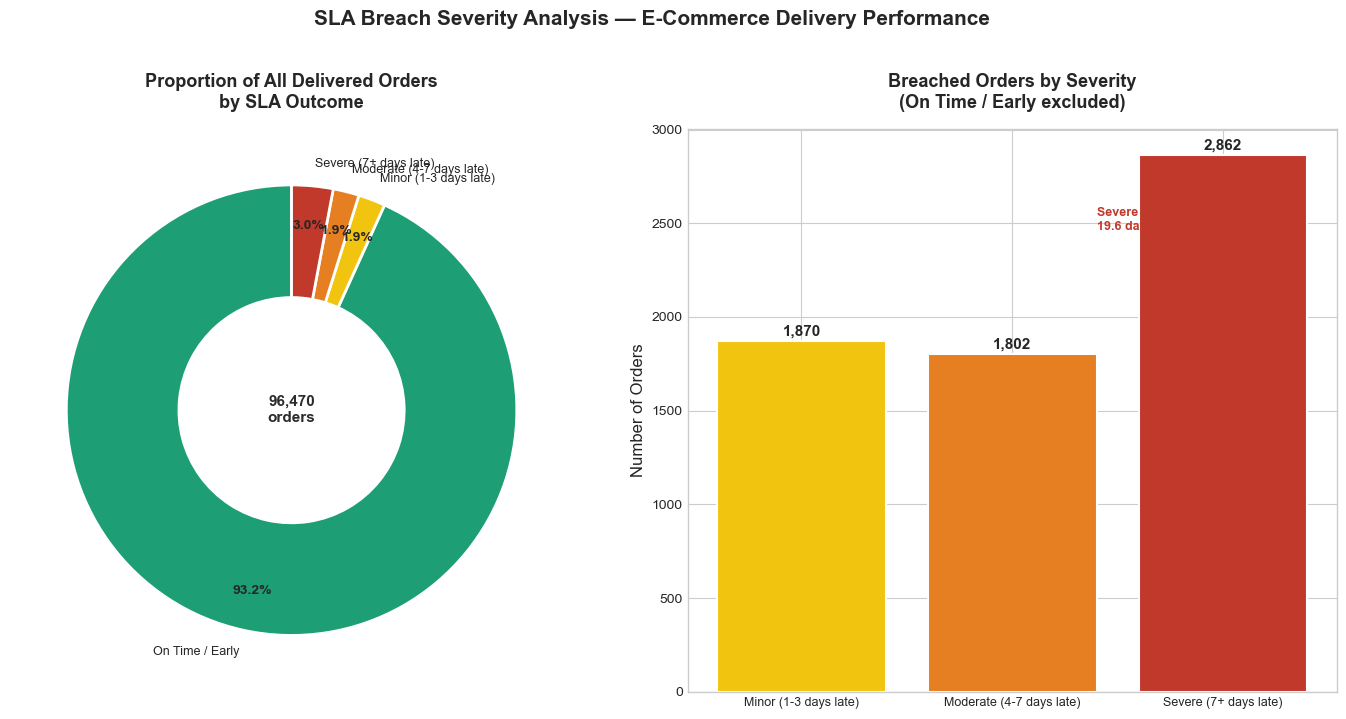

Chart 2 saved ✅

Severity breakdown:
                severity  count
         On Time / Early  89936
   Minor (1-3 days late)   1870
Moderate (4-7 days late)   1802
   Severe (7+ days late)   2862


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Define order and colours — green to red progression
severity_order = [
    'On Time / Early',
    'Minor (1-3 days late)',
    'Moderate (4-7 days late)',
    'Severe (7+ days late)'
]
colors = ['#1D9E75', '#F1C40F', '#E67E22', '#C0392B']

severity_counts = (df['breach_severity']
                     .value_counts()
                     .reindex(severity_order)
                     .reset_index())
severity_counts.columns = ['severity', 'count']

# ── Left: Donut chart (all orders) ──────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    severity_counts['count'],
    labels=severity_counts['severity'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    pctdistance=0.82,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight('bold')
for t in texts:
    t.set_fontsize(9)

axes[0].set_title('Proportion of All Delivered Orders\nby SLA Outcome',
                  fontsize=13, fontweight='bold', pad=15)

# Add total orders in donut centre
axes[0].text(0, 0, f'{len(df):,}\norders',
             ha='center', va='center', fontsize=11, fontweight='bold',
             color='#2C2C2A')

# ── Right: Bar chart (breached orders only) ──────────────────────────────────
breached_only = severity_counts[severity_counts['severity'] != 'On Time / Early']
bars = axes[1].bar(breached_only['severity'], breached_only['count'],
                   color=colors[1:], edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, breached_only['count']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

axes[1].set_ylabel('Number of Orders', fontsize=12)
axes[1].set_title('Breached Orders by Severity\n(On Time / Early excluded)',
                  fontsize=13, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', labelsize=9)

# Add platform context annotation
severe_count = severity_counts[
    severity_counts['severity'] == 'Severe (7+ days late)'
]['count'].values[0]
axes[1].annotate(f'Severe breaches avg\n19.6 days late',
                 xy=(2, severe_count), xytext=(1.4, severe_count - 400),
                 fontsize=9, color='#C0392B', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.2))

plt.suptitle('SLA Breach Severity Analysis — E-Commerce Delivery Performance',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../charts/02_severity_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved ✅")
print(f"\nSeverity breakdown:")
print(severity_counts.to_string(index=False))